# Task 4 — Step 4: PROSER — Classifier and Data Placeholders

PROSER (Zhou et al., 2021) prepares a closed-set classifier for unknowns without seeing any. Let $z\in\mathbb{R}^{10}$ be the known logits and $d\in\mathbb{R}^{5}$ the **dummy** (placeholder) logits on the same 512-d feature. The augmented classifier is $\hat f(x)=[z_1,\dots,z_{10},\max_m d_m]$, whose 11th output means "unknown".

**Classifier placeholders** ($\beta=1$). For a known example, once its true logit is removed, the strongest dummy should be the largest remaining response:
$$\ell_{\text{clf}}=\ell_{\text{CE}}\big(\hat f(x)\setminus z_y,\;K{+}1\big)$$
so the dummies learn a region *just outside* every known class, a class-specific rejection boundary.

**Data placeholders** ($\gamma=0.1$). Manifold mixup after `layer2` between two images of **different** classes:
$$\tilde h=\lambda\,\phi_{\text{pre}}(x_i)+(1-\lambda)\,\phi_{\text{pre}}(x_j),\quad y_i\neq y_j,\quad \lambda\sim\text{Beta}(2,2),\qquad \ell_{\text{data}}=\ell_{\text{CE}}\big(\hat f(\tilde h),K{+}1\big)$$
Mixed representations sit between known-class regions and serve as proxy unknowns.

**Objective:** $\ell_{\text{CE}}(\hat f(x),y)+\beta\,\ell_{\text{clf}}+\gamma\,\ell_{\text{data}}$. Each mini-batch is split in half, in the manual's order: the **first half** gets CE + classifier placeholders, the **second half** builds data placeholders.

**Setup (manual).** Initialised from the selected Vanilla checkpoint plus 5 randomly initialised dummies; **50 epochs** (`PROSER_EPOCHS`, as in the manual), SGD lr 1e-3, momentum 0.9, wd 5e-4, cosine, batch 128, seed 6304, vanilla augmentation; checkpoint chosen by CIFAR-10 validation accuracy on the **10 known logits**. No CIFAR-100 image participates in either placeholder. Code: `task4_open_set/src/proser.py`.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if not os.path.isdir(os.path.join(ROOT, 'task4_open_set')) and os.path.isdir('/content/task4_open_set'):
    ROOT = '/content'                    # running on a Colab server (see 0_colab_setup.ipynb)
sys.path.insert(0, ROOT)

import torch, torch.nn.functional as F, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from shared.src.seed import set_seed, SEED
from shared.src.plotting import use_style, SEQ_CMAP, PALETTE, NEUTRAL, INK_2, color_of, save_show
from shared.src.diagrams import proser_diagram
from task4_open_set.src.data import get_cifar10, make_loader, CIFAR10_CLASSES, TRAIN_TF, denorm
from task4_open_set.src.resnet_cifar import ResNetCIFAR
from task4_open_set.src.train import train_proser, extract_outputs, PROSER_EPOCHS
from task4_open_set.src.proser import augmented_logits, different_class_partner
from task4_open_set.src.scores import proser_score

use_style()
set_seed(SEED)
device = torch.device('cuda')
T4 = os.path.join(ROOT, 'task4_open_set')
CKPT, CACHE, RES = [os.path.join(T4, d) for d in ('checkpoints', 'cache', 'results')]
train_aug, train_plain, val_ds, test_ds = get_cifar10(TRAIN_TF)

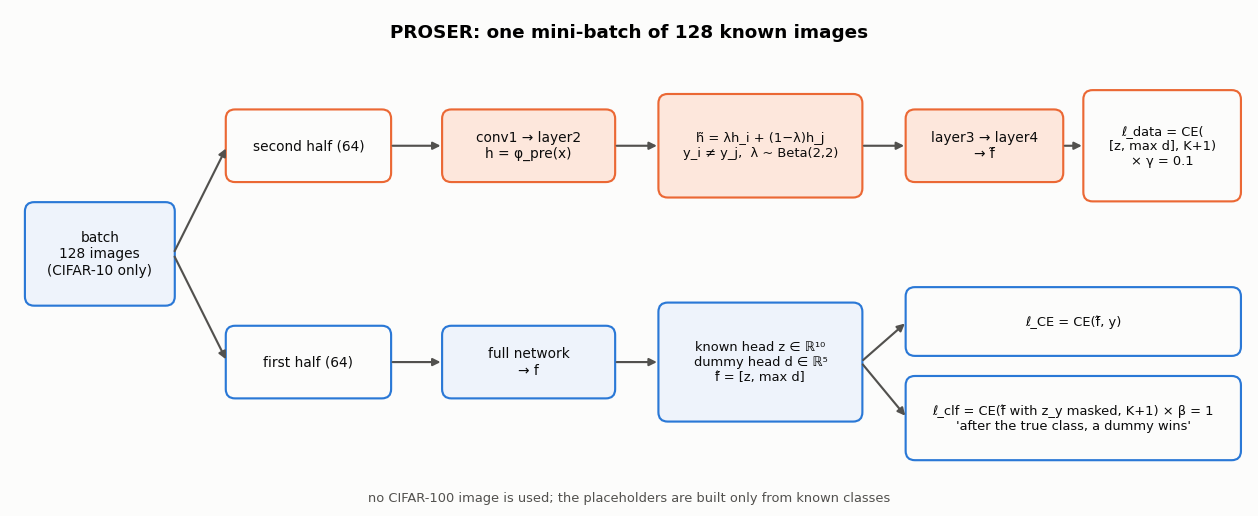

In [2]:
fig = proser_diagram()
save_show(fig, os.path.join(RES, 'proser_diagram.png'))

## 1. Initialise from Vanilla and append 5 dummy classifiers

In [3]:
def build_proser_from_vanilla():
    set_seed(SEED)
    m = ResNetCIFAR(num_classes=10)
    m.load_state_dict(torch.load(os.path.join(CKPT, 'vanilla.pth'), map_location='cpu', weights_only=True))
    m.add_dummies(5)             # random init (seeded)
    return m
model = build_proser_from_vanilla()
print('dummy head:', model.dummy, '| known head:', model.fc)

dummy head: Linear(in_features=512, out_features=5, bias=True) | known head: Linear(in_features=512, out_features=10, bias=True)


## 2. Fine-tune with classifier + data placeholders

In [4]:
FORCE_TRAIN = True
ckpt_path, hist_path = os.path.join(CKPT, 'proser.pth'), os.path.join(CKPT, 'proser_history.json')
CONFIG = dict(init='vanilla.pth', num_dummy=5, epochs=PROSER_EPOCHS, lr=1e-3, momentum=0.9, weight_decay=5e-4, schedule='cosine (per step)',
              batch_size=128, beta=1.0, gamma=0.1, mixup='layer2, Beta(2,2), different-class pairs', seed=SEED)
if FORCE_TRAIN or not os.path.exists(ckpt_path):
    model = build_proser_from_vanilla()
    out = train_proser(model, make_loader(train_aug, True, 128), make_loader(val_ds, False, 512), device,
                       epochs=PROSER_EPOCHS, lr=1e-3, beta=1.0, gamma=0.1, seed=SEED, save_path=ckpt_path, log_every=1)
    hist, best_epoch = out['history'], out['best_epoch']
    json.dump({'config': CONFIG, 'history': hist, 'best_epoch': best_epoch, 'best_val_acc': out['best_val_acc']}, open(hist_path, 'w'), indent=1)
else:
    meta = json.load(open(hist_path)); hist, best_epoch = meta['history'], meta['best_epoch']
model = ResNetCIFAR(num_classes=10, num_dummy=5).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
print(f'selected epoch {best_epoch} | val acc (10 known logits) {max(hist["val_acc"]):.4f}')

mixed precision: torch.float16
ep   1 | total 0.520 | ce 0.089 | clf-ph 0.143 | data-ph 2.875 | val acc 0.9490 * | 19s
ep   2 | total 0.333 | ce 0.106 | clf-ph 0.016 | data-ph 2.113 | val acc 0.9502 * | 18s
ep   3 | total 0.323 | ce 0.103 | clf-ph 0.013 | data-ph 2.065 | val acc 0.9512 * | 18s
ep   4 | total 0.311 | ce 0.102 | clf-ph 0.012 | data-ph 1.973 | val acc 0.9508 | 17s
ep   5 | total 0.308 | ce 0.103 | clf-ph 0.012 | data-ph 1.939 | val acc 0.9492 | 17s
ep   6 | total 0.274 | ce 0.099 | clf-ph 0.013 | data-ph 1.618 | val acc 0.9494 | 17s
ep   7 | total 0.167 | ce 0.074 | clf-ph 0.019 | data-ph 0.739 | val acc 0.9446 | 17s
ep   8 | total 0.120 | ce 0.052 | clf-ph 0.019 | data-ph 0.501 | val acc 0.9482 | 17s
ep   9 | total 0.092 | ce 0.041 | clf-ph 0.018 | data-ph 0.336 | val acc 0.9446 | 17s
ep  10 | total 0.091 | ce 0.039 | clf-ph 0.017 | data-ph 0.352 | val acc 0.9400 | 18s
ep  11 | total 0.303 | ce 0.092 | clf-ph 0.011 | data-ph 2.006 | val acc 0.9472 | 18s
ep  12 | total 0.

## 3. Training dynamics

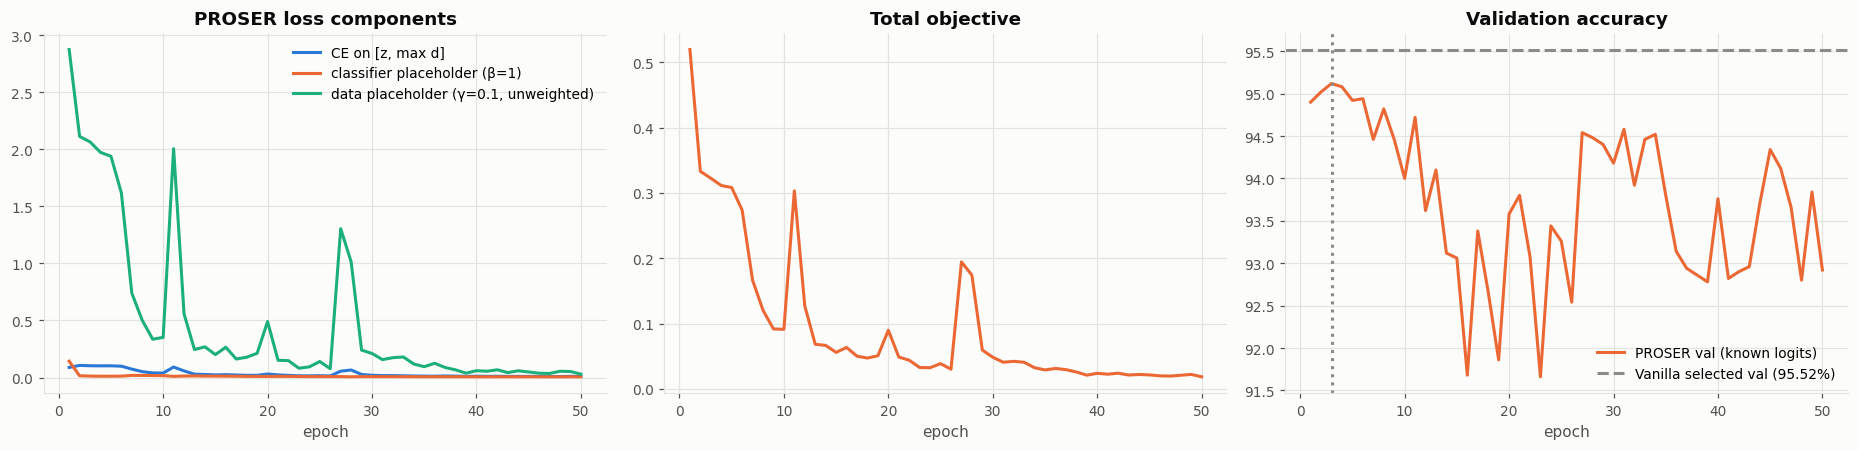

In [5]:
van = json.load(open(os.path.join(CKPT, 'vanilla_history.json')))
ep = np.arange(1, len(hist['loss']) + 1)
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(17, 4.2))
a1.plot(ep, hist['ce'], color=PALETTE[0], label='CE on [z, max d]')
a1.plot(ep, hist['clf_placeholder'], color=PALETTE[1], label='classifier placeholder (β=1)')
a1.plot(ep, hist['data_placeholder'], color=PALETTE[2], label='data placeholder (γ=0.1, unweighted)')
a1.set_title('PROSER loss components'); a1.set_xlabel('epoch'); a1.legend()
a2.plot(ep, hist['loss'], color=color_of('PROSER')); a2.set_title('Total objective'); a2.set_xlabel('epoch')
a3.plot(ep, 100 * np.array(hist['val_acc']), color=color_of('PROSER'), label='PROSER val (known logits)')
a3.axhline(100 * van['best_val_acc'], color=color_of('Vanilla'), ls='--', label=f"Vanilla selected val ({100*van['best_val_acc']:.2f}%)")
a3.axvline(best_epoch, color=NEUTRAL, ls=':'); a3.set_title('Validation accuracy'); a3.set_xlabel('epoch'); a3.legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'proser_training_curves.png'))

## 4. Closed-set accuracy (10 known logits only) and cached outputs

In [6]:
loaders = {'train': make_loader(train_plain, False, 512), 'val': make_loader(val_ds, False, 512), 'test': make_loader(test_ds, False, 512)}
outs = {k: extract_outputs(model, l, device) for k, l in loaders.items()}
np.savez_compressed(os.path.join(CACHE, 'proser_known.npz'), **{f'{k}_{f}': v for k, o in outs.items() for f, v in o.items()})
csa = (outs['test']['logits'].argmax(1) == outs['test']['labels']).mean()
json.dump({'csa': float(csa)}, open(os.path.join(RES, 'proser_csa.json'), 'w'))
csa_v = json.load(open(os.path.join(RES, 'vanilla_csa.json')))['csa']
aug_pred = augmented_logits(torch.tensor(outs['test']['logits']), torch.tensor(outs['test']['dummy'])).argmax(1).numpy()
print(f"CSA (10 known logits): Vanilla {100*csa_v:.2f}% -> PROSER {100*csa:.2f}% ({100*(csa-csa_v):+.2f} pp)")
print(f"known test images whose strongest output is the dummy: {100*(aug_pred==10).mean():.2f}%")

CSA (10 known logits): Vanilla 94.81% -> PROSER 94.35% (-0.46 pp)
known test images whose strongest output is the dummy: 8.73%


## 5. Where do the data placeholders live?
One t-SNE fit (seed 6304, perplexity 30, PCA init) on penultimate features of 1,000 known validation images and 300 manifold-mixup placeholders built from validation pairs of different classes. If the mechanism works as intended, placeholders fall *between* the class clusters and the dummy head responds to them.

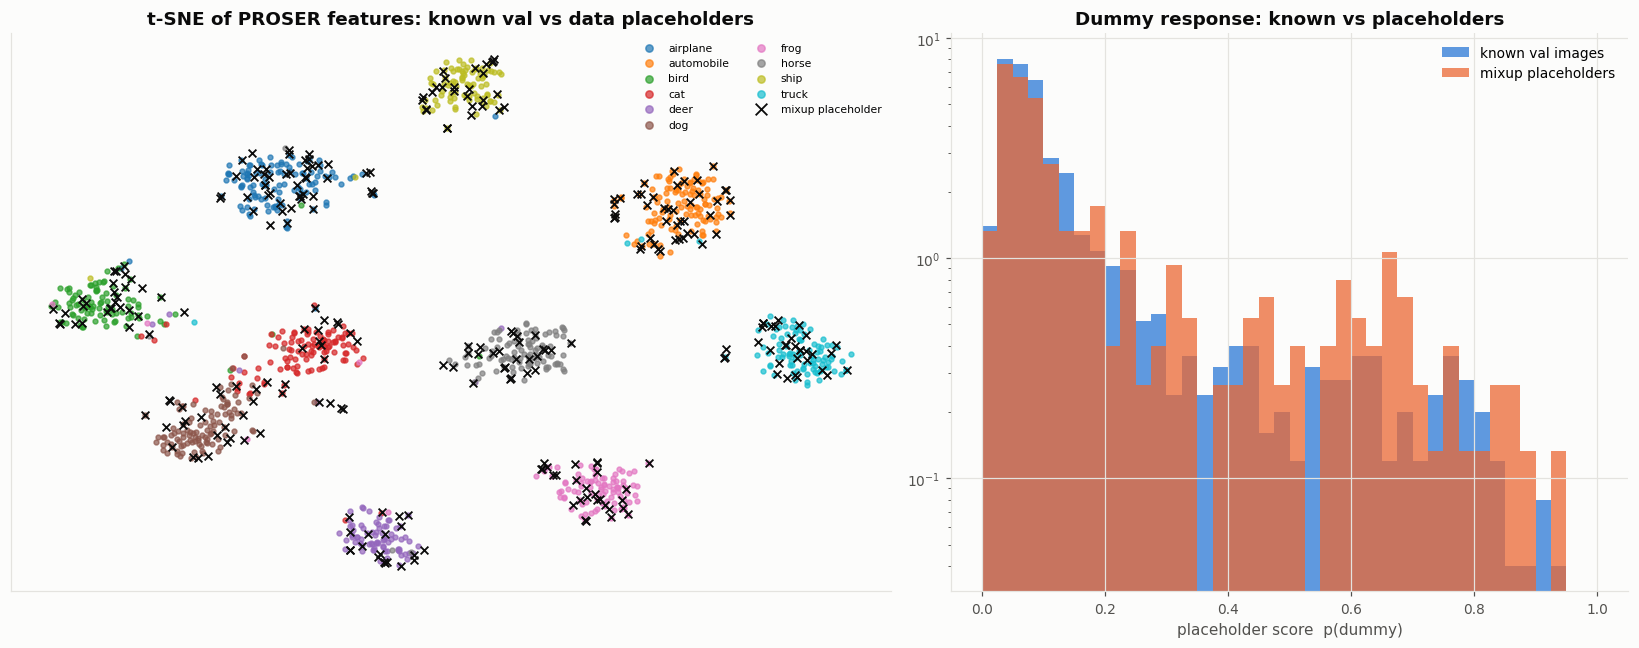

In [7]:
set_seed(SEED)
model.eval()
g = torch.Generator().manual_seed(SEED)
idx = np.random.RandomState(SEED).choice(len(val_ds), 1000, replace=False)
xv = torch.stack([val_ds[int(i)][0] for i in idx]).to(device); yv = torch.tensor([val_ds[int(i)][1] for i in idx]).to(device)
with torch.no_grad():
    zk, fk, dk = model(xv)
    h = model.pre_mix(xv[:300]); j = different_class_partner(yv[:300], g); keep = j >= 0
    lam = torch.distributions.Beta(2., 2.).sample((int(keep.sum()), 1, 1, 1)).to(device)
    zm, fm, dm = model.forward_from_mid(lam * h[keep] + (1 - lam) * h[j[keep]])
emb = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(np.concatenate([fk.cpu().numpy(), fm.cpu().numpy()]))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.3, 1]})
cmap10 = plt.get_cmap('tab10')
for c in range(10):
    s = (yv.cpu().numpy() == c)
    a1.scatter(emb[:1000][s, 0], emb[:1000][s, 1], s=10, color=cmap10(c), alpha=0.7, label=CIFAR10_CLASSES[c])
a1.scatter(emb[1000:, 0], emb[1000:, 1], s=26, marker='x', color='#0b0b0b', lw=1.2, label='mixup placeholder')
a1.set_title('t-SNE of PROSER features: known val vs data placeholders'); a1.legend(ncol=2, fontsize=7, markerscale=1.5); a1.set_xticks([]); a1.set_yticks([])
s_known = proser_score(zk.cpu().numpy(), dk.cpu().numpy()); s_mix = proser_score(zm.cpu().numpy(), dm.cpu().numpy())
bins = np.linspace(0, 1, 41)
a2.hist(s_known, bins=bins, color=PALETTE[0], alpha=0.75, density=True, label='known val images')
a2.hist(s_mix, bins=bins, color=PALETTE[1], alpha=0.75, density=True, label='mixup placeholders')
a2.set_yscale('log'); a2.set_xlabel('placeholder score  p(dummy)'); a2.set_title('Dummy response: known vs placeholders'); a2.legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'proser_placeholder_tsne.png'))

## 5b. Data placeholders as pictures
Six validation pairs from **different** classes (seed 6304). Their layer2 activations are mixed with λ ~ Beta(2, 2), and the mixture is passed through layer3 → head. Each row shows the two source images, the sampled λ, PROSER's strongest known class and probability for the mixture, and the placeholder score p(dummy). Only the mixture (a feature, not an image) is seen by the network, so it is shown as text.

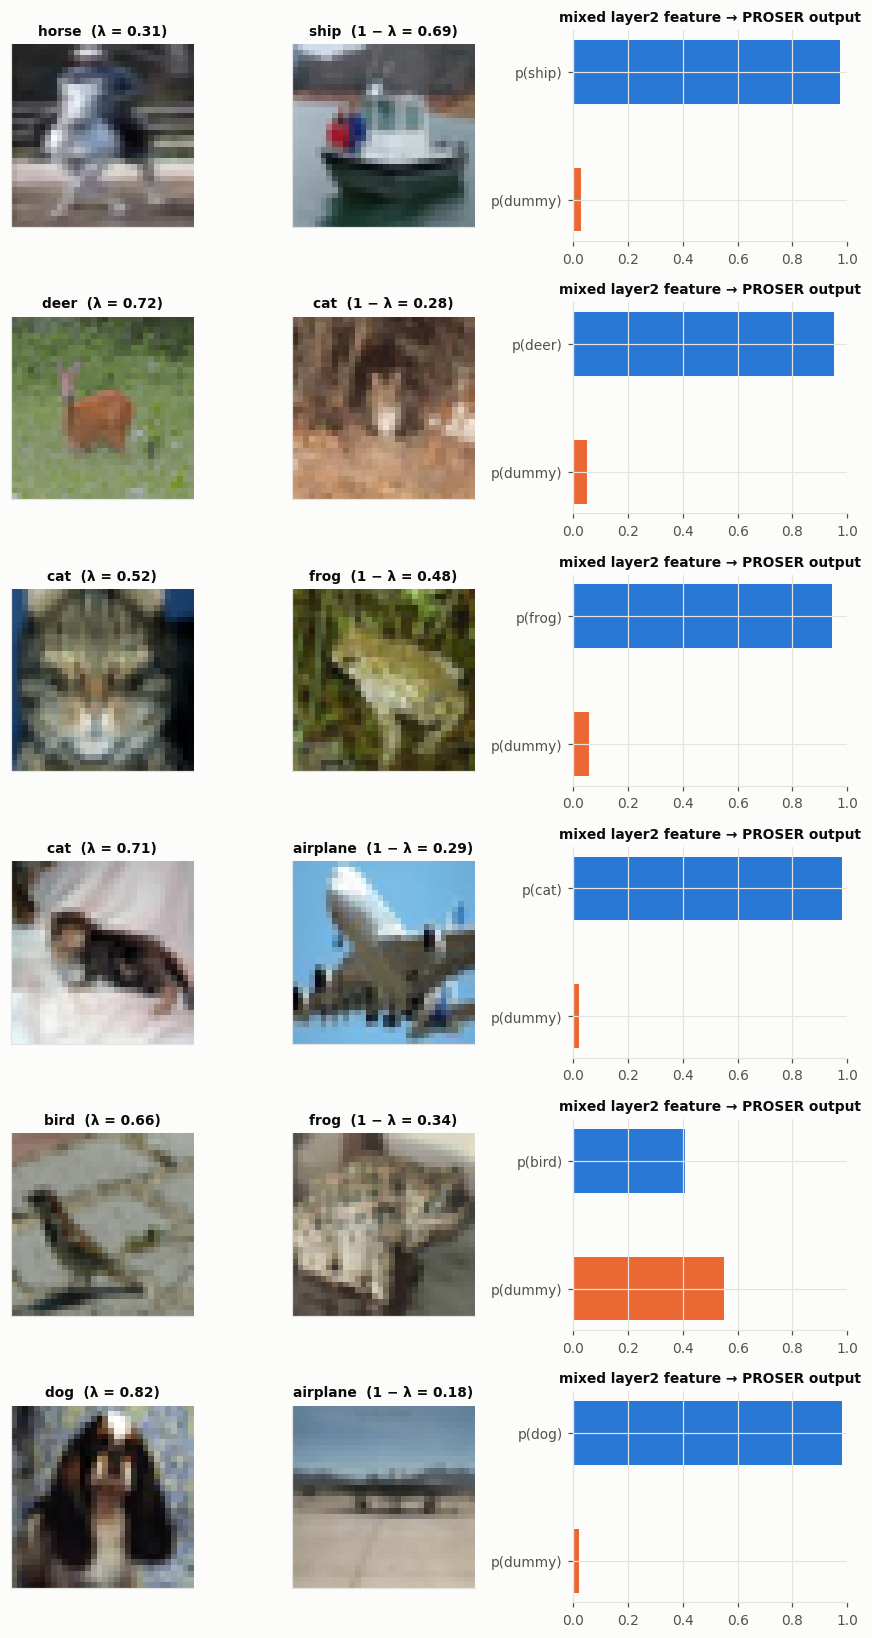

In [8]:
g2 = torch.Generator().manual_seed(SEED + 1); rs = np.random.RandomState(SEED + 1)
fig, axes = plt.subplots(6, 3, figsize=(8, 15), gridspec_kw={'width_ratios': [1, 1, 1.5]})
with torch.no_grad():
    for r in range(6):
        while True:
            i, j = rs.choice(len(val_ds), 2, replace=False)
            if val_ds[int(i)][1] != val_ds[int(j)][1]: break
        (xi, yi), (xj, yj) = val_ds[int(i)], val_ds[int(j)]
        lam = float(rs.beta(2, 2))
        h = lam * model.pre_mix(xi[None].to(device)) + (1 - lam) * model.pre_mix(xj[None].to(device))
        z, _, d = model.forward_from_mid(h)
        p = torch.softmax(augmented_logits(z, d), 1)[0].cpu().numpy()
        axes[r, 0].imshow(denorm(xi)); axes[r, 0].set_title(f'{CIFAR10_CLASSES[yi]}  (λ = {lam:.2f})', fontsize=9)
        axes[r, 1].imshow(denorm(xj)); axes[r, 1].set_title(f'{CIFAR10_CLASSES[yj]}  (1 − λ = {1-lam:.2f})', fontsize=9)
        axes[r, 2].barh(['p(dummy)', f'p({CIFAR10_CLASSES[p[:10].argmax()]})'], [p[10], p[:10].max()], color=[PALETTE[1], PALETTE[0]], height=0.5)
        axes[r, 2].set_xlim(0, 1); axes[r, 2].set_title('mixed layer2 feature → PROSER output', fontsize=9)
        for a in axes[r, :2]: a.set_xticks([]); a.set_yticks([]); a.grid(False)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'proser_mixup_pairs.png'))

## 5c. Walking between two classes: Vanilla vs PROSER
For five validation pairs of different classes, the layer2 activations are interpolated with λ from 0 to 1 and pushed through the rest of each network. Vanilla can only express doubt through its softmax confidence (left). PROSER can also route probability to its dummy placeholder (right, dashed). If the placeholders work as intended, the dummy probability peaks between the two class regions.

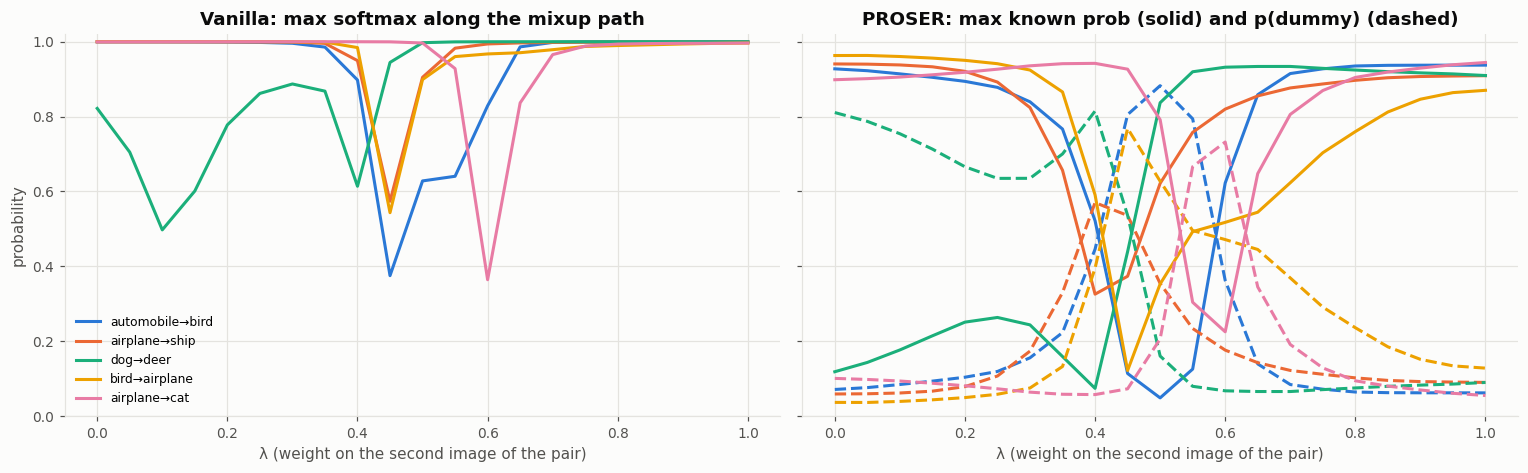

In [9]:
vanilla = ResNetCIFAR(num_classes=10).to(device); vanilla.load_state_dict(torch.load(os.path.join(CKPT, 'vanilla.pth'), map_location=device, weights_only=True)); vanilla.eval()
lams = np.linspace(0, 1, 21); rs = np.random.RandomState(SEED + 2)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
with torch.no_grad():
    for k in range(5):
        while True:
            i, j = rs.choice(len(val_ds), 2, replace=False)
            if val_ds[int(i)][1] != val_ds[int(j)][1]: break
        xi, xj = val_ds[int(i)][0][None].to(device), val_ds[int(j)][0][None].to(device)
        hv = [vanilla.pre_mix(xi), vanilla.pre_mix(xj)]; hp = [model.pre_mix(xi), model.pre_mix(xj)]
        conf_v, conf_p, dum_p = [], [], []
        for l in lams:
            zv = vanilla.forward_from_mid(l * hv[0] + (1 - l) * hv[1])[0]; conf_v.append(torch.softmax(zv, 1).max().item())
            z, _, d = model.forward_from_mid(l * hp[0] + (1 - l) * hp[1]); pp = torch.softmax(augmented_logits(z, d), 1)[0]
            conf_p.append(pp[:10].max().item()); dum_p.append(pp[10].item())
        lab = f'{CIFAR10_CLASSES[val_ds[int(j)][1]]}→{CIFAR10_CLASSES[val_ds[int(i)][1]]}'
        a1.plot(lams, conf_v, color=PALETTE[k], label=lab)
        a2.plot(lams, conf_p, color=PALETTE[k], label=f'{lab}: max known'); a2.plot(lams, dum_p, '--', color=PALETTE[k])
a1.set_title('Vanilla: max softmax along the mixup path'); a2.set_title('PROSER: max known prob (solid) and p(dummy) (dashed)')
for a in (a1, a2): a.set_xlabel('λ (weight on the second image of the pair)'); a.set_ylim(0, 1.02)
a1.set_ylabel('probability'); a1.legend(fontsize=8); fig.tight_layout()
save_show(fig, os.path.join(RES, 'proser_interpolation_paths.png'))

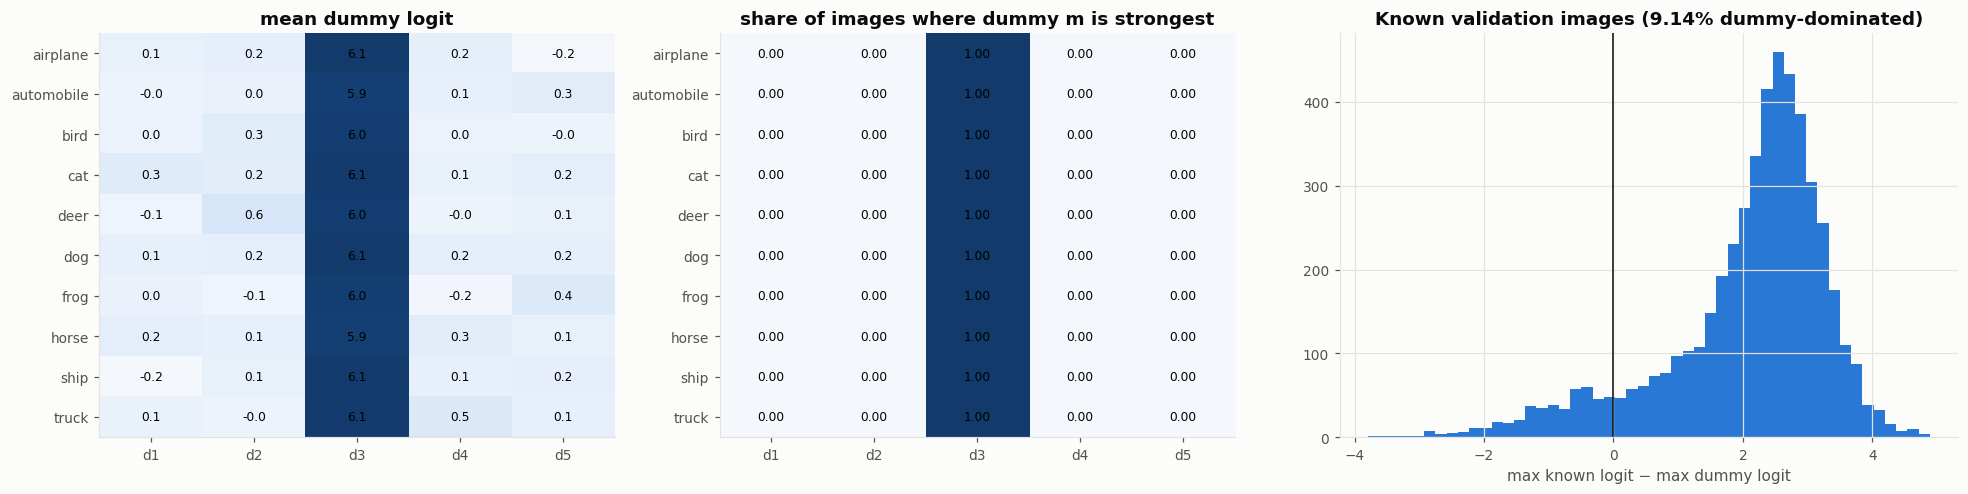

In [10]:
# Which dummy responds to which known class? Mean dummy logit per true class (known validation images)
dv, yv_all = outs['val']['dummy'], outs['val']['labels']
M = np.stack([dv[yv_all == c].mean(0) for c in range(10)])
share = np.stack([np.bincount(dv[yv_all == c].argmax(1), minlength=5) / (yv_all == c).sum() for c in range(10)])
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(18, 4.6), gridspec_kw={'width_ratios': [1, 1, 1.2]})
for ax, A, t, fmt in [(a1, M, 'mean dummy logit', '{:.1f}'), (a2, share, 'share of images where dummy m is strongest', '{:.2f}')]:
    im = ax.imshow(A, cmap=SEQ_CMAP, aspect='auto')
    for i in range(10):
        for j in range(5): ax.text(j, i, fmt.format(A[i, j]), ha='center', va='center', fontsize=8)
    ax.set_xticks(range(5)); ax.set_xticklabels([f'd{m+1}' for m in range(5)]); ax.set_yticks(range(10)); ax.set_yticklabels(CIFAR10_CLASSES); ax.grid(False); ax.set_title(t)
gap = outs['val']['logits'].max(1) - dv.max(1)
a3.hist(gap, bins=50, color=PALETTE[0]); a3.axvline(0, color='#0b0b0b', lw=1)
a3.set_xlabel('max known logit − max dummy logit'); a3.set_title(f'Known validation images ({100*(gap < 0).mean():.2f}% dummy-dominated)')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'proser_dummy_behaviour.png'))

## 6. Operating points fixed on known validation data
Two scores are defined for PROSER before any unknown is seen:
- **MLS on the 10 known logits**, $u=-\max_k z_k$, directly comparable with Vanilla and GCSC.
- **Placeholder score** (reference implementation): $u_{\text{PROSER}}=\operatorname{softmax}\big([z,\max_m d_m]\big)_{K+1}$, the probability mass assigned to the strongest dummy.

For each score, τ is the 95th percentile on CIFAR-10 validation.

In [11]:
rows = []
for name, uv, ut in [('MLS (known logits)', -outs['val']['logits'].max(1), -outs['test']['logits'].max(1)),
                     ('Placeholder score', proser_score(outs['val']['logits'], outs['val']['dummy']), proser_score(outs['test']['logits'], outs['test']['dummy']))]:
    tau = np.percentile(uv, 95)
    rows.append({'score': name, 'tau': tau, 'known val accept (%)': 100 * (uv <= tau).mean(), 'known test accept (%)': 100 * (ut <= tau).mean()})
pd.DataFrame(rows).set_index('score').round(4)

,tau,known val accept (%),known test accept (%)
score,,,
MLS (known logits),-4.9752,95.0,94.67
Placeholder score,0.6158,95.0,94.75
